### Search engine with Tools and Agents


In [1]:
## Tools and wrappers
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper


In [2]:
# api->query run
api_wrapper_key_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=256)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_key_wiki)
wiki.name

'wikipedia'

In [3]:
api_wrapper_key_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_key_arxiv)
arxiv.name

'arxiv'

In [4]:
tools=[arxiv,wiki]

In [5]:
#RAG elements
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['HF_TOKEN']=os.getenv('HF_TOKEN')


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
loader=WebBaseLoader("https://docs.smith.langchain.com/")
docs=loader.load()
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectordb=FAISS.from_documents(documents,embeddings)
retriever=vectordb.as_retriever()
retriever


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1373.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7fe6e5537400>, search_kwargs={})

In [7]:
from langchain_classic.tools.retriever import create_retriever_tool
retriever_tool=create_retriever_tool(retriever,"langsmithsearch","The tool is used to search about Langsmith")
retriever_tool

StructuredTool(name='langsmithsearch', description='The tool is used to search about Langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x7fe6e5556a70>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x7fe6e5556b00>)

In [8]:
tools=[arxiv,wiki,retriever_tool]
print(tools)

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)), WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/hp/Documents/GenAI/LangChain/lib/python3.10/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=256)), StructuredTool(name='langsmithsearch', description='The tool is used to search about Langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x7fe6e5556a70>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x7fe6e5556b00>)]


In [48]:
#Lets combine tools and LLM Models
from langchain_groq import ChatGroq
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
llm=ChatGroq(model_name="openai/gpt-oss-120b",temperature=0)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fe6b7724760>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fe6b7742350>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

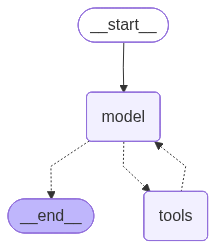

In [49]:
#Agents, new one no need to prompts .The agent use langgraph and they have already knowledge about input and using scrathpad
from langchain.agents import create_agent
#llm=llm.bind_tools(tools)
agent=create_agent(llm,tools,system_prompt="You are an helpful assistant,first refer the retrievr tool ,if you cant find the answer search wiki tool and atlast search the arxiv tool. ")
agent

In [50]:
response=agent.invoke({"messages":
              [("user","Tell me about LangSmith")]})

In [51]:
response['messages'][-1].content

'**LangSmith – An Overview**\n\nLangSmith is a **framework‑agnostic observability, evaluation, and deployment platform** built by the LangChain team for anyone building AI agents, LLM‑driven applications, or other generative‑AI services. It gives developers a single place to **trace, debug, test, evaluate, and ship** their AI code, whether they are using LangChain, LangGraph, LangServe, or any other stack.\n\n---\n\n## Core Capabilities\n\n| Capability | What It Does | Why It Matters |\n|------------|--------------|----------------|\n| **Observability** | Records every step of a request (prompt, model call, tool use, response, metadata). Provides a searchable trace UI and a CLI for querying traces. | Makes it possible to pinpoint failures, understand latency bottlenecks, and reproduce bugs quickly. |\n| **Evaluation** | Lets you define evaluation criteria (e.g., correctness, relevance, safety) and run them automatically on new runs or historic data. Results are stored as experiments th

In [52]:
for i in agent.stream({'messages':[("user","Tell me about Machine learning")]}):
    i

In [82]:
## Prompt Template
import langchainhub as hub
from langsmith import Client
client=Client()
prompt=client.pull_prompt("hwchase17/openai-functions-agent")
prompt.messages


[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [53]:
from langgraph.prebuilt import create_react_agent

from langchain_core.prompts import ChatPromptTemplate
#arxiv,wiki,retriever_tool
system_prompt = """You are a research assistant with three tools:
1. langsmithsearch — try this FIRST for domain-specific questions about LangSmith, LangChain, etc.
2. wikipedia — for general public knowledge
3. arxiv — for academic/research paper questions
IMPORTANT: Always use a tool to look up information. Never answer from memory alone."""
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
agent_langgraph=create_react_agent(llm_with_tools,tools,prompt=system_prompt)

/tmp/ipykernel_16428/1501508563.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_langgraph=create_react_agent(llm_with_tools,tools,prompt=system_prompt)


In [45]:
for tool in tools:
    print(tool.name)


arxiv
wikipedia
langsmithsearch


In [54]:
response=agent_langgraph.invoke({'messages':[('user','Tell me about Langsmith')]})

In [55]:
response['messages'][-1].content

'**LangSmith – Overview**\n\nLangSmith is a **framework‑agnostic observability, evaluation, and deployment platform** for AI agents and LLM‑powered applications. It is built by the LangChain team and is designed to give developers a single place to **trace, debug, test, evaluate, and manage** their AI workloads from local development all the way to production.\n\n---\n\n### Core Capabilities\n\n| Capability | What it does | Why it matters |\n|------------|--------------|----------------|\n| **Observability** | Automatically records every step of a request (inputs, LLM calls, tool calls, outputs, metadata). | Gives you a full “debug trace” so you can pinpoint failures, latency spikes, or unexpected model behavior. |\n| **Evaluation** | Lets you define evaluation criteria (e.g., correctness, relevance, safety) and run them on stored traces or on new data. | Tracks quality over time, surfaces regressions, and provides quantitative metrics for monitoring. |\n| **Prompt Engineering** | Buil

In [56]:
response_outside_docs=agent_langgraph.invoke({'messages':[('user','Tell me about machine learning')]})

In [57]:
response_outside_docs['messages'][-1].content

'**Machine Learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to **learn from data** and make predictions or decisions without being explicitly programmed for each specific task. In other words, instead of writing hard‑coded rules, we let the system infer patterns, relationships, and rules directly from examples.\n\n---\n\n## 1. Core Concepts\n\n| Concept | Description |\n|---------|-------------|\n| **Data** | The raw material for learning—examples, measurements, or observations. Data can be labeled (supervised) or unlabeled (unsupervised). |\n| **Model** | A mathematical representation (e.g., a neural network, decision tree, or linear equation) that maps inputs to outputs. |\n| **Training** | The process of adjusting model parameters (weights, thresholds, etc.) to minimize a loss function on the training data. |\n| **Generalization** | The ability of a trained model to perform well on **uns

In [59]:
response_outside_docs=agent_langgraph.invoke({'messages':[('user','Who is sharukh khan')]})

In [60]:
response_outside_docs

{'messages': [HumanMessage(content='Who is sharukh khan', additional_kwargs={}, response_metadata={}, id='7c9576e0-385d-4c07-91da-6f45585654ec'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Who is sharukh khan". Likely they mean Shah Rukh Khan, Indian actor. Need to use Wikipedia tool.', 'tool_calls': [{'id': 'fc_32461312-e79b-434f-b3f3-707c4a5f949c', 'function': {'arguments': '{"query":"Shah Rukh Khan"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 341, 'total_tokens': 402, 'completion_time': 0.135157454, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.018553941, 'prompt_tokens_details': None, 'queue_time': 0.044363789, 'total_time': 0.153711395}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d59a6-f3

In [61]:
#error
response_outside_docs=agent_langgraph.invoke({'messages':[('user','Which country has high oil resources')]})

BadRequestError: Error code: 400 - {'error': {'message': "Tool call validation failed: tool call validation failed: parameters for tool wikipedia did not match schema: errors: [missing properties: 'query']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "wikipedia", "arguments": {"cursor": 0, "id": 0}}'}}

### Observations
- Agent Executor is depreciated 
- Use Langgraph,agents create_react_agent
- While passing prompt always pass a string and if you want to use tools mention the tool names properly
- For complex questions, it is failing

In [62]:
agent_langgraph.invoke({'messages':[('user','What is attention in Transformers')]})

{'messages': [HumanMessage(content='What is attention in Transformers', additional_kwargs={}, response_metadata={}, id='dcb626e3-48db-4326-83e4-52918aadf65d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is attention in Transformers". Need to answer. According to developer instructions, must use a tool to look up information. This is a general question about Transformers (machine learning). Could use Wikipedia. Use wikipedia tool to search "Attention mechanism (machine learning)" or "Transformer (machine learning)". Let\'s search.', 'tool_calls': [{'id': 'fc_6a2e8996-df48-4fac-867e-4117df04245c', 'function': {'arguments': '{"query":"Attention mechanism transformer"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 340, 'total_tokens': 436, 'completion_time': 0.199801691, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.013308647, 'prompt_tokens_det